# Redundancy in hidden Transformer layers - audio model similarity

*Commands to reproduce audio model results regarding CKA and cosine similarity of intermediate layers:*

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.style.use('ggplot')

cmaps = {
    'cosine': 'RdGy',
    'cka': 'BrBG',
    'jacobian': 'RdBu',
}

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

In [2]:
def plot_similarity_matrices(experiments):
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        
        sim_type = 'cosine'
        similarities = results[f'all-{sim_type}-similarities']
        fig, axs = plt.subplots(2,2, figsize=(10, 10))
        for j, _loc in enumerate(['within', 'between']):
            sims = torch.stack([sim[_loc] for sim in similarities])
            _mean, _std = sims.mean(dim=0), sims.std(dim=0)

            for i, _sims in enumerate([_mean, _std]):
                norm = TwoSlopeNorm(vmin=min(_sims.min(), -1e-7), vcenter=0., vmax=max(_sims.max(), 1e-7))
                cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[sim_type])
                axs[i,j].imshow(_sims, cmap=cmaps[sim_type], norm=norm)
                axs[i,j].grid(False)
                axs[i,j].set_title(f'{_loc.capitalize()} blocks')
                fig.colorbar(cbar, ax=axs[i,j], fraction=0.04)

        fig.suptitle(f"{exp_name.capitalize()}\nCosine similarity", fontsize=18)
        plt.tight_layout()
        plt.show()

        sim_type = 'cka'
        similarities = results[f'all-{sim_type}-similarities']
        _mean, _std = torch.stack(similarities).mean(dim=0), torch.stack(similarities).std(dim=0)

        fig, axs = plt.subplots(2,2, figsize=(10, 10))
        for i, _sims in enumerate([_mean, _std]):
            for j, _loc in enumerate(['within', 'between']):
                norm = TwoSlopeNorm(vmin=min(_sims[j::2, j::2].min(), -1e-7), vcenter=0., vmax=max(_sims[j::2, j::2].max(), 1e-7))
                cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[sim_type])
                axs[i,j].imshow(_sims[j::2, j::2], cmap=cmaps[sim_type], norm=norm)
                axs[i,j].grid(False)
                axs[i,j].set_title(f'{_loc.capitalize()} blocks')
                fig.colorbar(cbar, ax=axs[i,j], fraction=0.04)

        fig.suptitle(f"{exp_name.capitalize()}\n{sim_type.capitalize()} similarity", fontsize=18)
        plt.tight_layout()
        plt.show()

### RoBERTa-base

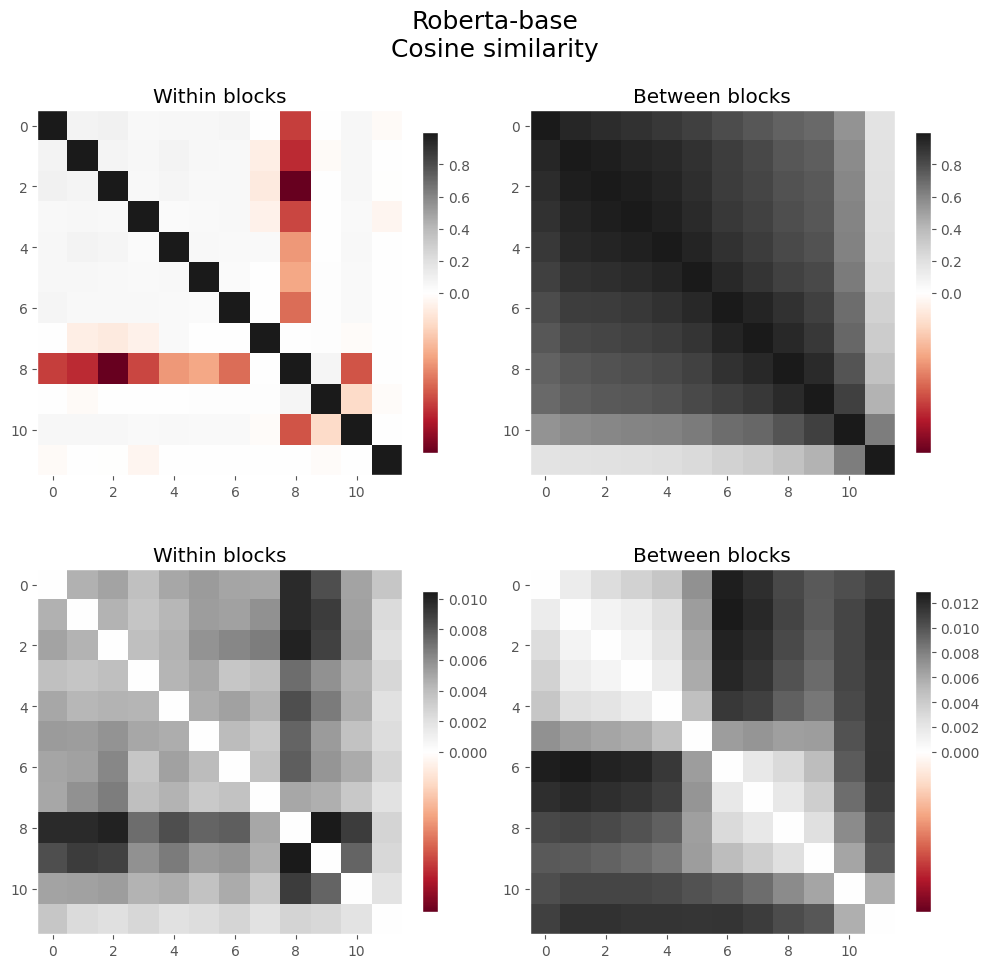

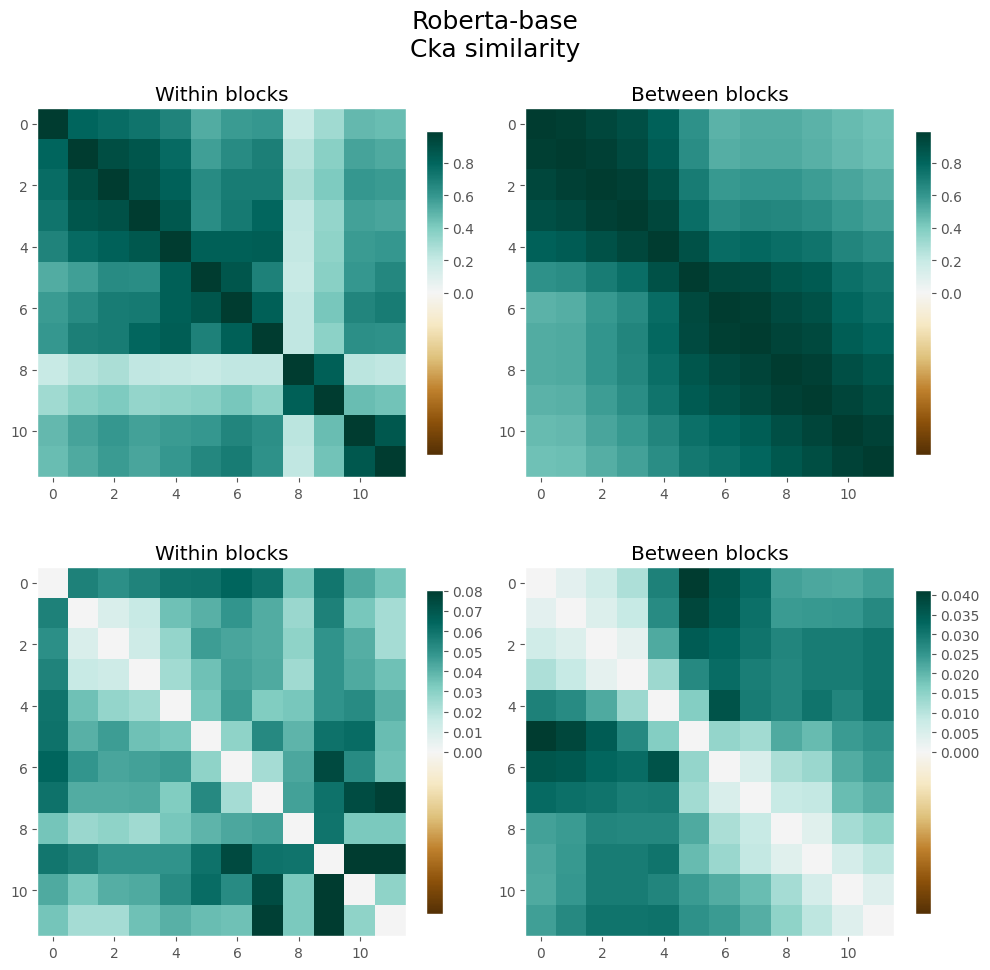

In [3]:
# DeiT experiments
experiments = {
    'roberta-base': EXP_PATH / "text/roberta-base-go_emotions/within=True_['cosine-similarity', 'cka-similarity']_results.pth",
}
# Plot similarity matrices for large model
plot_similarity_matrices(experiments)

## Block Influence scores (pruning)

In [4]:
def plot_block_influence(experiments, ax, res_per_exp=1):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        bi_scores = torch.vstack(results['all-block-influences'])
        n_samples, n_layers = bi_scores.shape
        color_idx += 1

        ax.plot(range(n_layers), bi_scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(range(n_layers), bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')

    ax.set_xticks(range(n_layers), [f'$\ell={i}$' for i in range(start_layer_idx, n_layers+start_layer_idx)])
    ax.set(xlabel='Layer index', ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

## Pruning

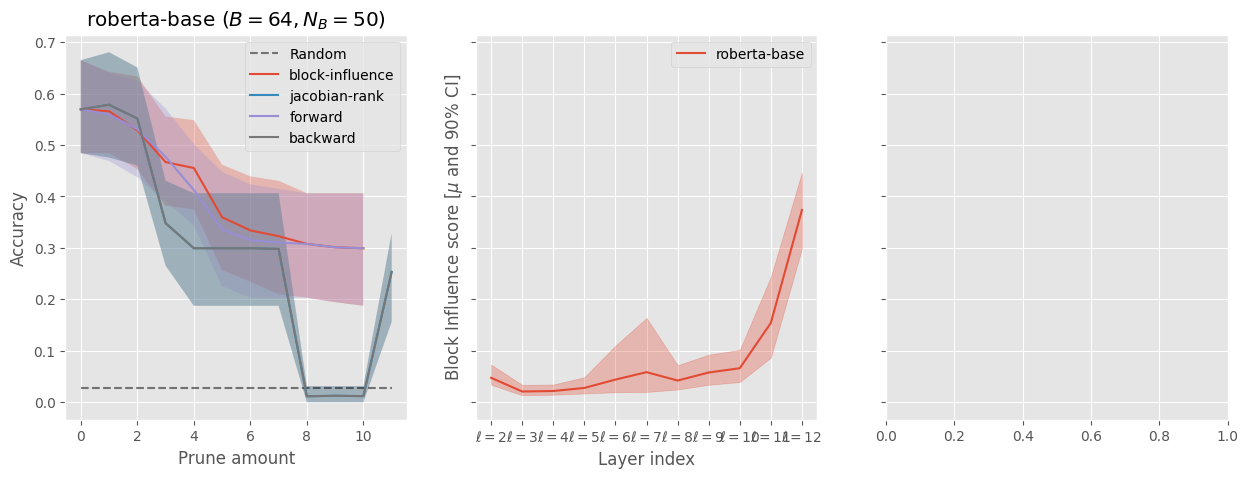

In [5]:
experiments = {
    'roberta-base': EXP_PATH / "text/roberta-base-go_emotions/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, (exp_name, exp_path) in enumerate(experiments.items()):
# results = torch.load(EXP_PATH / "audio/wavLM-words_within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-inference', 'jacobian-rank']_results.pth")
    results = torch.load(exp_path)
    results['all-block-influences'] = results['all-block-influences']
    n_batches = results['all-block-influences'].__len__()
    batch_size = results['all-block-influences'][0].shape[0]


    axs[i].hlines(1/35, xmin=0, xmax=11, color='black', linestyle='--', alpha=0.5, label='Random')
    for pruning_strategy in ['block-influence', 'jacobian-rank', 'forward', 'backward']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(0.05).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(0.95).item() for k, v in results['accuracy'][pruning_strategy].items()}
        axs[i].fill_between(mean_accs.keys(), list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[i].plot(mean_accs.keys(), list(mean_accs.values()), label=pruning_strategy)

    axs[i].legend()
    axs[i].set(xlabel='Prune amount', ylabel='Accuracy', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')

# Plot block influence scores
plot_block_influence(experiments, axs[i+1], res_per_exp=1)
axs[i+1].set_title('')

plt.show()